# Project 6: SPICE

This project will focus on implementing a simple version of SPICE (Simulation Program with 
Integrated Circuit Emphasis) with the capability of simulating transient and nonlinear circuit 
components. 

### Imports

In [71]:
from vpython import *
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image

### Part 1: Capacitor and Nodal Analysis

#### RC Filter

Parameters for components. R = 1000 and C = 1 microfarad are used as common values and they are easy to visualize. The time step is chosen to capture the frequency values used, gives 100 steps per cycle for a frequency of 1000.

In [50]:
#Resistor value in ohms
R  = 1000
#1 micro farad
C  = 1e-6
#Time step
dt = 1e-5

Get the equivalent values of the capacitor in the circuit

In [51]:
#Pass in the voltage to get equivalent capacitence and capacitor current
def capacitor_companion(Vb_prev, dt):
    Ceq  = C / dt
    ICeq = -(C / dt) * Vb_prev
    return Ceq, ICeq

Produces the A and b in the Ax = b equation to solve for our values

In [52]:
#Build the matrices for our system of equations
def build_mna_rc(Ceq, ICeq, Vi_now):
    #A and resulting b from notes
    A = np.array([
        [-1/R,       1/R,        1],
        [ 1/R,  -1/R - Ceq,      0],
        [   1,         0,         0]], dtype=float)
 
    b = np.array([0, ICeq, Vi_now], dtype=float)
 
    return A, b

Now use these functions in the total calculation loop. Frequency values used to check come from the R and C used. f = 1/(2 * pi * R * C) = 159 Hz, this is the cutoff. The loop is run for T_END/5, which allows for five full cylces to be run.

In [59]:
#For updating
Vb_prev = 0.0

#Peak voltage
VP = 5

#Sine wave frequencies
F_vals = [50, 159, 2000]

all_results = []

#For every frequency
for F in F_vals:
    #Omega used with sine wave
    OMEGA = 2 * np.pi * F

    #Initial model
    Ceq, ICeq = capacitor_companion(Vb_prev, dt)
    
    #Store states
    t_hist = []
    Vi_hist = []
    Vb_hist = []

    #Time goes from 0 to 5/freq
    t = 0.0
    T_END = 5/F

    #Time simulatiomn loop
    while t <= T_END:
        #Input voltage update
        Vi_now = VP * np.sin(OMEGA * t)
    
        #Solve
        A, b = build_mna_rc(Ceq, ICeq, Vi_now)
        x    = np.linalg.solve(A, b)
        Va, Vb, IVi = x
    
        #Store
        t_hist.append(t)
        Vi_hist.append(Vi_now)
        Vb_hist.append(Vb)
    
        #Update capacitor equivalent values
        Ceq, ICeq = capacitor_companion(Vb, dt)
        t += dt
    #Append to one list for graphing
    all_results.append((F, t_hist, Vi_hist, Vb_hist))

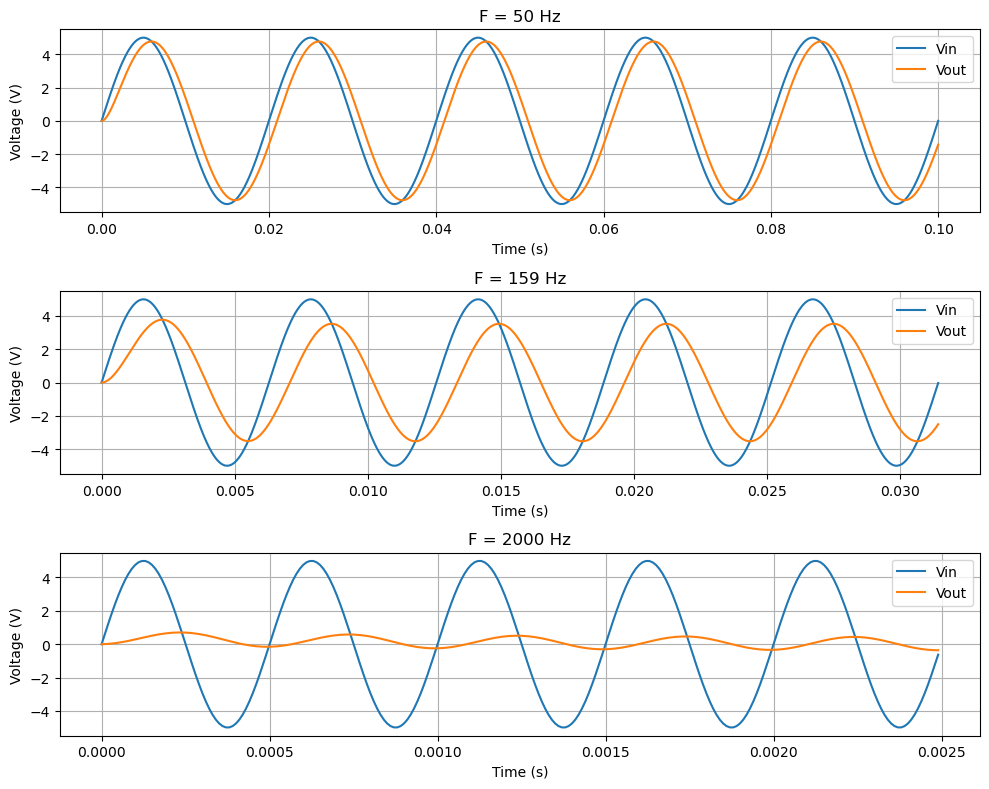

In [60]:
#Plot
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=False)

for i, (f, t_hist, Vi_hist, Vb_hist) in enumerate(all_results):
    axes[i].plot(t_hist, Vi_hist, label="Vin")
    axes[i].plot(t_hist, Vb_hist, label="Vout")
    axes[i].set_title(f"F = {f} Hz")
    axes[i].set_xlabel("Time (s)")
    axes[i].set_ylabel("Voltage (V)")
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

Using the different frequencies, we can see the cycle time of the output wave as well as the amplitude change. With increasee frequency, the voltage is reduced further, which is the expected result. These frequencies were chosen as 159 is the cutoff frequency, 50 is lower, and 2000 is significantly higher.

#### LT Spice Verification

The same resistor and capacitor values were used and the voltage was made as a sine wave with different frequencies depending on the trial. Time step and length of simulation was also adjusted appropriately

![LTSpice RC_Filter](rc_circuit.png)

For a frequency of 50 hz:

![LTSpice 50Hz](50_hz.png)

For a frequency of 159 hz:

![LTSpice 159Hz](159_hz.png)

For a frequency of 2000 hz:

![LTSpice 2000Hz](2000_hz.png)

All of these graphs look as expected. First, the cycles change with our different frequency values. The same simulation times are used and we can observe very similar behavior of seeing 5 full cycles. We can also observe the reduced voltages. Voltage continually decreases as the frequencies increase, and the values shown are consistent with the simulation results

### Part 2: Diode

#### Parameters

IS and VT are chosen from looking up the proper values. n=1 is used for an ideal scenario as this is a simulation. R is chosen from the schematic provided in lecture.

In [63]:
#Parameters for diode
IS = 1e-14
VT = 0.02585
#1 for ideal
n  = 1 

#From schematic
R  = 100e3

#### Half Wave Rectifier

Functions for diode equivalent circuit

In [64]:
#Diode current equation
def diode_current(Vd):
    #Clip for stable values
    return IS * (np.exp(np.clip(Vd, -10*n*VT, 700*n*VT) / (n*VT)) - 1)

#Given voltage, get the GDeq and IDeq for the matrices
def diode_companion(Vd_op):
    #Clip for stable values
    Vd_clip = np.clip(Vd_op, -10*n*VT, 700*n*VT)
    #From notes
    GDeq = (IS / (n * VT)) * np.exp(Vd_clip / (n * VT))
    IDeq = diode_current(Vd_clip) - GDeq * Vd_clip
    return GDeq, IDeq

Build the a and b matrices

In [65]:
#Build the a and b matrices
def build_mna_rectifier(GDeq, IDeq, Ceq, ICeq, Vi_now):
    #From lecture
    A = np.array([
        [-GDeq,              GDeq,          1],
        [ GDeq,  -GDeq - Ceq - 1/R,        0],
        [    1,                  0,         0]], dtype=float)
 
    b = np.array([
        IDeq,
        ICeq - IDeq,
        Vi_now], dtype=float)
 
    return A, b 

Create the simulation loop. Peak voltage of 5 and frequency of 1000 are consistent with the schematic provided from lecture. Once again, the simulation is runfor 5 full cycles. The timestep is chosen to capture 100 cycles per second for a frequency of 1000. Tolerance value is also suggested from lecture and the max iterations is a high value chosen as an overestimate.

In [68]:
#First guess
Vb_prev = 0.0
VQ = 0.6

#For sine wave
VP    = 5.0
F     = 1000
OMEGA = 2 * np.pi * F

#Timing
T_END = 5 / F
dt = 1e-5

#Max iterations as safety
NR_MAX = 100

#MAx error
NR_TOL = 0.001

#Initial component models
Ceq, ICeq  = capacitor_companion(Vb_prev, dt)
GDeq, IDeq = diode_companion(VQ)

#Store results
t_hist  = []
Vi_hist = []
Va_hist = []
Vb_hist = []

t = 0.0
#For time limit
while t <= T_END:
    Vi_now = VP * np.sin(OMEGA * t)
    Vd_guess = VQ
    for iteration in range(NR_MAX):
        #Companion model
        GDeq, IDeq = diode_companion(Vd_guess)
        Ceq, ICeq  = capacitor_companion(Vb_prev, dt)
        #Solve for next stage voltage
        A, b = build_mna_rectifier(GDeq, IDeq, Ceq, ICeq, Vi_now)
        x = np.linalg.solve(A, b)
        Va, Vb, IVi = x
        Vd_new = Va - Vb
        #If the guess is close enough
        if abs(Vd_new - Vd_guess) < NR_TOL:
            break
        Vd_guess = Vd_new
    else:
        #If we didn't converge in our cycle limit, reduce dt
        dt /= 2
        #Error out for too small of t
        if dt < 1e-12:
            raise RuntimeError(f"Time step too small at t={t:.6e}s")
        VQ = 0.6
        continue
    VQ     = Vd_new
    Vb_prev = Vb
    #Update capacitor model
    Ceq, ICeq = capacitor_companion(Vb_prev, dt)
    #Store times and voltages
    t_hist.append(t)
    Vi_hist.append(Vi_now)
    Va_hist.append(Va)
    Vb_hist.append(Vb)
    #Increment time
    t += dt
    #Reset time step
    dt = 1e-5

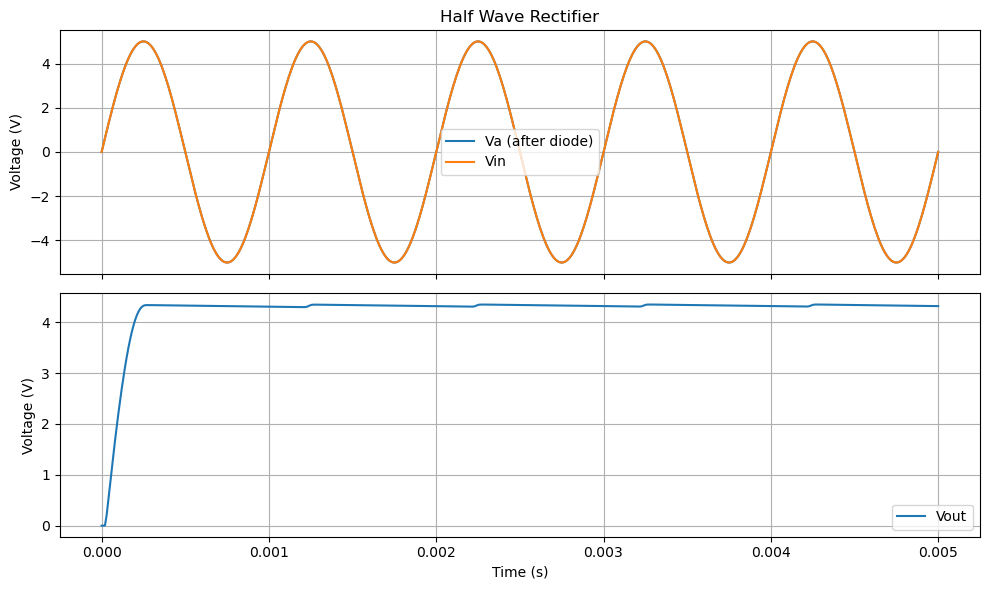

In [72]:
#Plot
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(t_hist, Va_hist, label="Va (after diode)")
axes[0].plot(t_hist, Vi_hist, label="Vin")
axes[0].set_ylabel("Voltage (V)")
axes[0].set_title("Half Wave Rectifier")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t_hist, Vb_hist, label="Vout")
axes[1].set_ylabel("Voltage (V)")
axes[1].set_xlabel("Time (s)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In the graph comparing both Va and Vin, one line appears. This is because these values are the exact same, and this is verified through the system of equations. The Vout remains positive and slightly reduced from the diode, with small ripples. This is as expected and confirms the behavior of the half-wave rectifier.

#### LTSpice Verification

The schematic was produced with the same voltage parameters, resistance, and capacitance. 

![LTSpice Half_wave_circuit](half_wave_rec.png)

![LTSpice Half_wave](half_wave.png)

This graph of the V_Out for our half-wave rectifier shos exactly what our simulation results produced. The voltage starts at 0 and increases quickly, then levels off at around 4.4V. If you look closely, you can also see the rippling that occurs in the simulation graph. This is strong proof that our simulation is working as expected

### Analysis

#### Effect of changing the time constant

The same simulation will be ran but with a much smaller resistance which will change our time constant significantly

In [73]:
#Parameters for diode
IS = 1e-14
VT = 0.02585
#1 for ideal
n  = 1 

#From schematic
##########
#New value
#########
R  = 100

In [74]:
#First guess
Vb_prev = 0.0
VQ = 0.6

#For sine wave
VP    = 5.0
F     = 1000
OMEGA = 2 * np.pi * F

#Timing
T_END = 5 / F
dt = 1e-5

#Max iterations as safety
NR_MAX = 100

#MAx error
NR_TOL = 0.001

#Initial component models
Ceq, ICeq  = capacitor_companion(Vb_prev, dt)
GDeq, IDeq = diode_companion(VQ)

#Store results
t_hist  = []
Vi_hist = []
Va_hist = []
Vb_hist = []

t = 0.0
#For time limit
while t <= T_END:
    Vi_now = VP * np.sin(OMEGA * t)
    Vd_guess = VQ
    for iteration in range(NR_MAX):
        #Companion model
        GDeq, IDeq = diode_companion(Vd_guess)
        Ceq, ICeq  = capacitor_companion(Vb_prev, dt)
        #Solve for next stage voltage
        A, b = build_mna_rectifier(GDeq, IDeq, Ceq, ICeq, Vi_now)
        x = np.linalg.solve(A, b)
        Va, Vb, IVi = x
        Vd_new = Va - Vb
        #If the guess is close enough
        if abs(Vd_new - Vd_guess) < NR_TOL:
            break
        Vd_guess = Vd_new
    else:
        #If we didn't converge in our cycle limit, reduce dt
        dt /= 2
        #Error out for too small of t
        if dt < 1e-12:
            raise RuntimeError(f"Time step too small at t={t:.6e}s")
        VQ = 0.6
        continue
    VQ     = Vd_new
    Vb_prev = Vb
    #Update capacitor model
    Ceq, ICeq = capacitor_companion(Vb_prev, dt)
    #Store times and voltages
    t_hist.append(t)
    Vi_hist.append(Vi_now)
    Va_hist.append(Va)
    Vb_hist.append(Vb)
    #Increment time
    t += dt
    #Reset time step
    dt = 1e-5

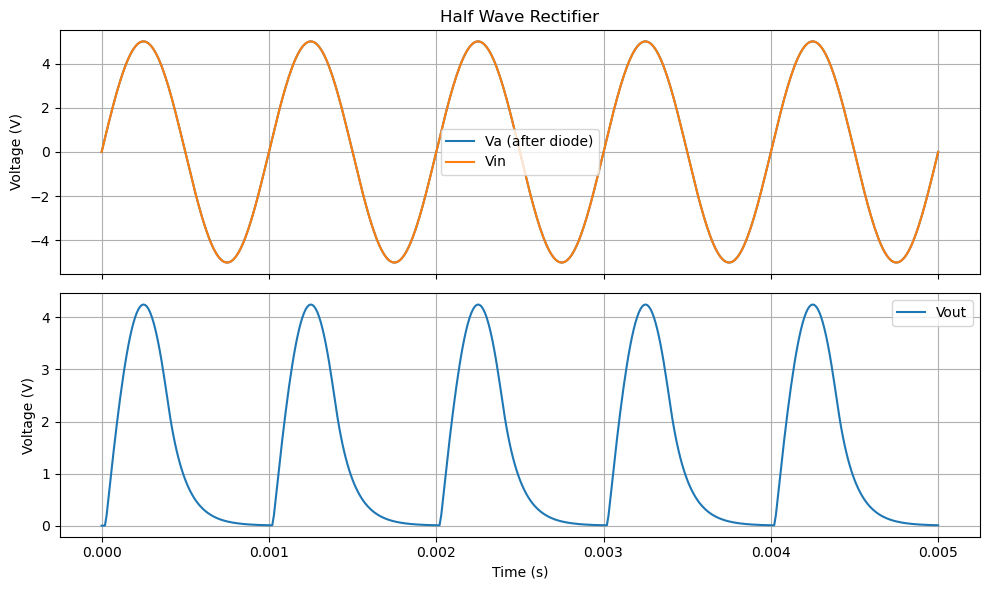

In [75]:
#Plot
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(t_hist, Va_hist, label="Va (after diode)")
axes[0].plot(t_hist, Vi_hist, label="Vin")
axes[0].set_ylabel("Voltage (V)")
axes[0].set_title("Half Wave Rectifier")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t_hist, Vb_hist, label="Vout")
axes[1].set_ylabel("Voltage (V)")
axes[1].set_xlabel("Time (s)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Reducing the resistor's value from 100,000 to 100 created a much different waveform. The ripple here is much more noticeable, and we can see the capacitor discharge much more. The time constant was reduced to be much smaller than the period here and produces different behavior. R or C would be changed to either createa smoother waveform or more rippling.

#### Converging Time Steps vs Non-Converging

The time step will be reduced to find a value that results in non-convergance

In [76]:
#Parameters for diode
IS = 1e-14
VT = 0.02585
#1 for ideal
n  = 1 

#From schematic
R  = 100000

In [81]:
#First guess
Vb_prev = 0.0
VQ = 0.6

#For sine wave
VP    = 5.0
F     = 1000
OMEGA = 2 * np.pi * F

#Timing
T_END = 5 / F
###########
#New value
###########
dt = 1e-3

#Max iterations as safety
NR_MAX = 100

#MAx error
NR_TOL = 0.001

#Initial component models
Ceq, ICeq  = capacitor_companion(Vb_prev, dt)
GDeq, IDeq = diode_companion(VQ)

#Store results
t_hist  = []
Vi_hist = []
Va_hist = []
Vb_hist = []

t = 0.0
#For time limit
while t <= T_END:
    Vi_now = VP * np.sin(OMEGA * t)
    Vd_guess = VQ
    for iteration in range(NR_MAX):
        #Companion model
        GDeq, IDeq = diode_companion(Vd_guess)
        Ceq, ICeq  = capacitor_companion(Vb_prev, dt)
        #Solve for next stage voltage
        A, b = build_mna_rectifier(GDeq, IDeq, Ceq, ICeq, Vi_now)
        x = np.linalg.solve(A, b)
        Va, Vb, IVi = x
        Vd_new = Va - Vb
        #If the guess is close enough
        if abs(Vd_new - Vd_guess) < NR_TOL:
            break
        Vd_guess = Vd_new
    else:
        #If we didn't converge in our cycle limit, reduce dt
        dt /= 2
        #Error out for too small of t
        if dt < 1e-12:
            raise RuntimeError(f"Time step too small at t={t:.6e}s")
        VQ = 0.6
        continue
    VQ     = Vd_new
    Vb_prev = Vb
    #Update capacitor model
    Ceq, ICeq = capacitor_companion(Vb_prev, dt)
    #Store times and voltages
    t_hist.append(t)
    Vi_hist.append(Vi_now)
    Va_hist.append(Va)
    Vb_hist.append(Vb)
    #Increment time
    t += dt
    #Reset time step
    dt = 1e-3

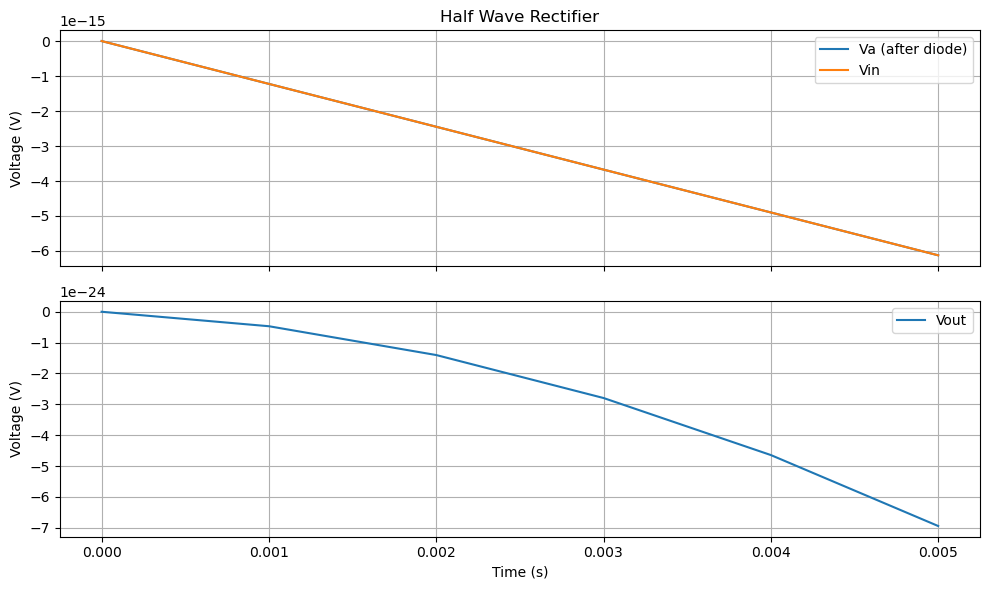

In [82]:
#Plot
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(t_hist, Va_hist, label="Va (after diode)")
axes[0].plot(t_hist, Vi_hist, label="Vin")
axes[0].set_ylabel("Voltage (V)")
axes[0].set_title("Half Wave Rectifier")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t_hist, Vb_hist, label="Vout")
axes[1].set_ylabel("Voltage (V)")
axes[1].set_xlabel("Time (s)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Changing the time step from 1e-5 to 1e-3 made it so that our model never converges. The step is far too big for how fast everything would change in the model with the given parameters. This result is meaningless and does not represent a real circuit. The voltage should follow a similar pattern as before, but we can see all of the voltages start at just above 0 and continually decrease. This emphasizes the importance of choosing a correct time step for simulation purposes